In [43]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time



In [5]:
api_key = "RqRq7h51fUy2Pqsq8dO3R03hkm1JELAflsF8HvSq"

### COL	Coal	Coal-fired plants.
### NG	Natural Gas	Gas-fired turbines or combined-cycle plants.
### SUN	Solar	Utility-scale PV or CSP (concentrated solar).
### OTH	Other (misc fuels)	Biomass, landfill gas, unknown/uncategorized.
### WAT	Water (Hydro)	Hydroelectric plants.
### WND	Wind	Wind turbines.

### D	Actual Demand: total daily electricity consumption (MWh) in LADWP’s balancing area.
### DF	Day-Ahead Forecast Demand: the predicted daily demand LADWP expected the day before.
### NG	Net Generation: total electricity generated within LADWP’s territory each day.
### TI	Interchange: net power imported (if positive) or exported (if negative) from LADWP’s region each day.


=== PART 1: DAILY FUEL-TYPE DATA (FULL) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 5000 rows (offset=10000)
Fetched 5000 rows (offset=15000)
Fetched 1368 rows (offset=20000)
Fetched 0 rows (offset=25000)

Total MWh by Fuel Type (Daily Fuel):
fueltype
NG     72695275.0
COL    32461686.0
SUN    29090800.0
OTH    15639774.0
WAT    10221694.0
WND     6008866.0
Name: MWh, dtype: float64


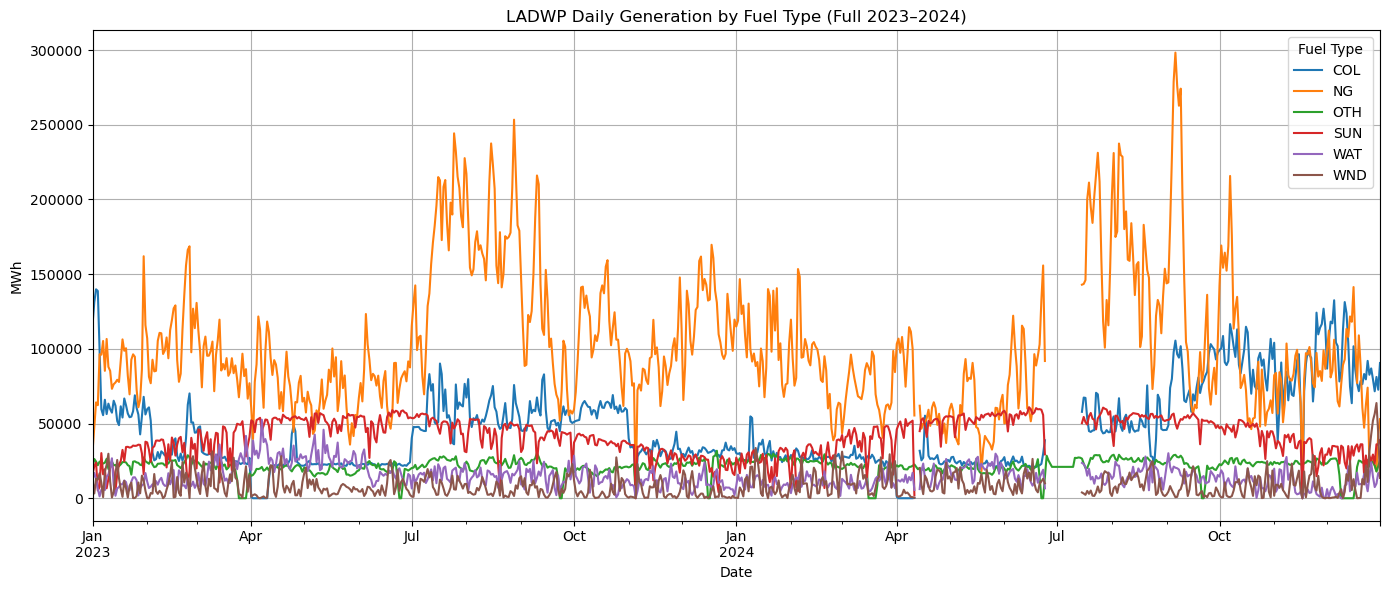


=== PART 2: HOURLY FUEL-TYPE DATA (FULL) ===
Fetched 5000 rows with offset 0
Fetched 5000 rows with offset 5000
Fetched 5000 rows with offset 10000
Fetched 5000 rows with offset 15000
Fetched 5000 rows with offset 20000
Fetched 5000 rows with offset 25000
Fetched 5000 rows with offset 30000
Fetched 5000 rows with offset 35000
Fetched 5000 rows with offset 40000
Fetched 5000 rows with offset 45000
Fetched 5000 rows with offset 50000
Fetched 5000 rows with offset 55000
Fetched 5000 rows with offset 60000
Fetched 5000 rows with offset 65000
Fetched 5000 rows with offset 70000
Fetched 5000 rows with offset 75000
Fetched 5000 rows with offset 80000
Fetched 5000 rows with offset 85000
Fetched 5000 rows with offset 90000
Fetched 5000 rows with offset 95000
Fetched 2204 rows with offset 100000
Fetched 0 rows with offset 105000

✅ Total MWh by Fuel Type (Full Hourly 2023–2024):
fueltype
NG     14521890.0
COL     6472765.0
SUN     5804133.0
OTH     3118381.0
WAT     2039585.0
WND     1199092.0


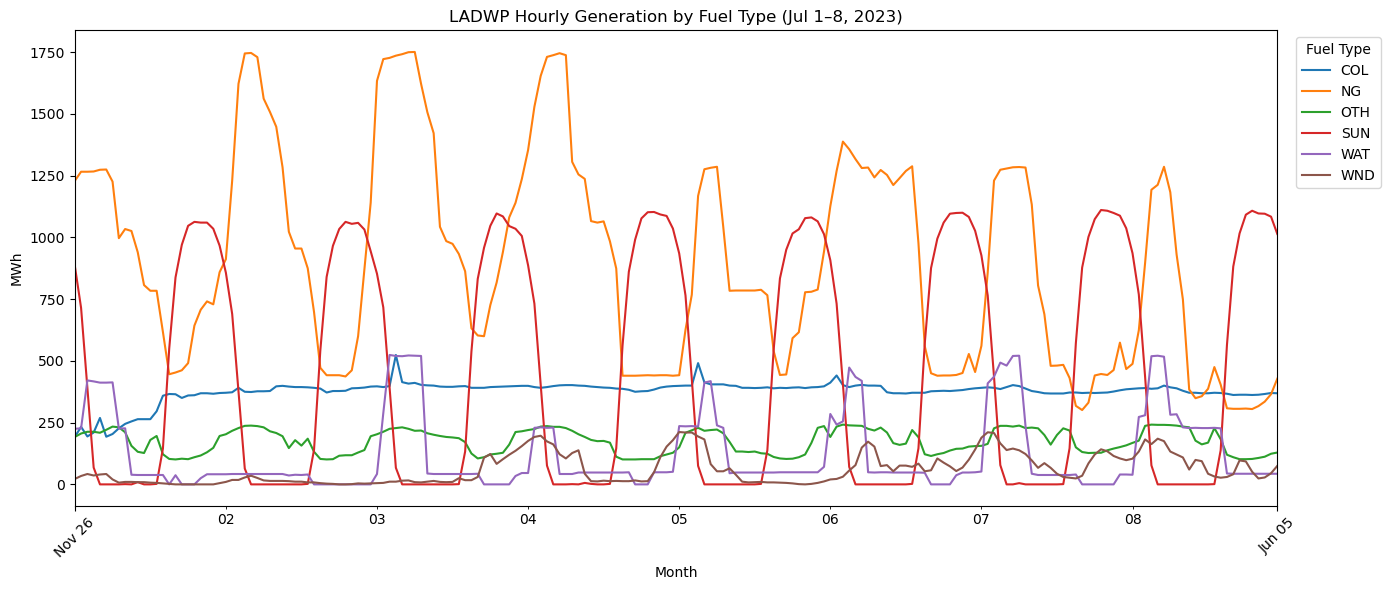


=== PART 3: DAILY REGION DATA (FULL) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 4549 rows (offset=10000)
Fetched 0 rows (offset=15000)

Available metrics (Daily Region): ['D', 'DF', 'NG', 'TI']
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


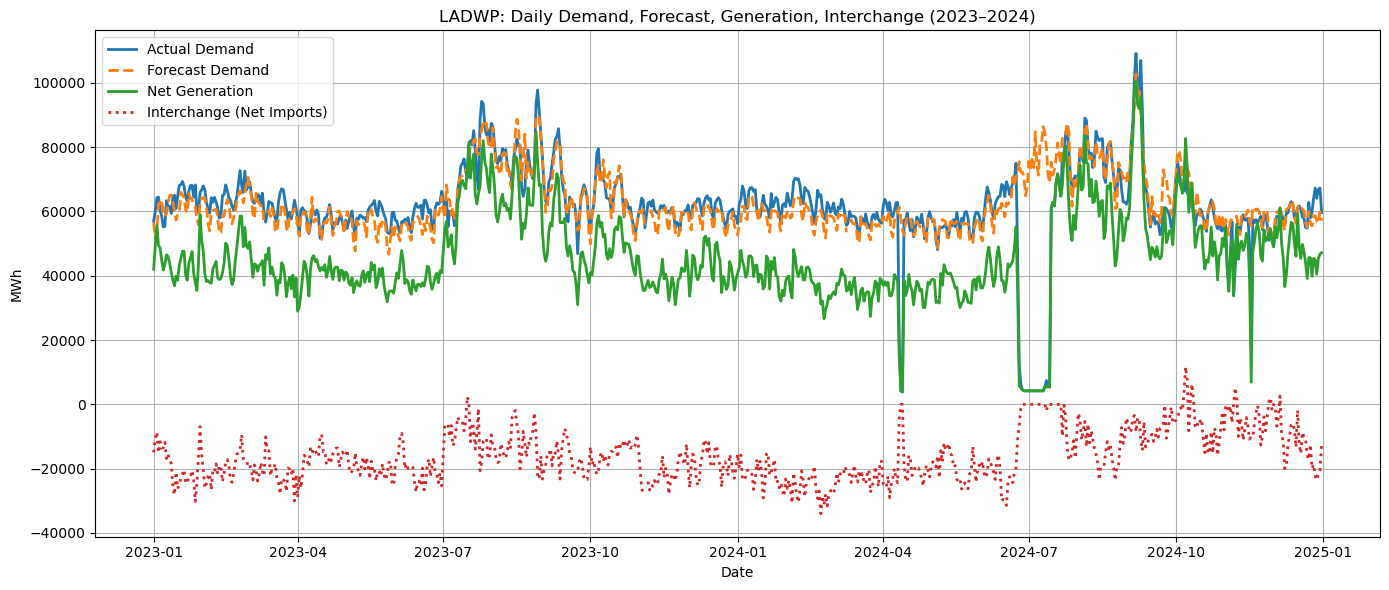


=== PART 4: HOURLY REGION DATA (FULL) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 5000 rows (offset=10000)
Fetched 5000 rows (offset=15000)
Fetched 5000 rows (offset=20000)
Fetched 5000 rows (offset=25000)
Fetched 5000 rows (offset=30000)
Fetched 5000 rows (offset=35000)
Fetched 5000 rows (offset=40000)
Fetched 5000 rows (offset=45000)
Fetched 5000 rows (offset=50000)
Fetched 5000 rows (offset=55000)
Fetched 5000 rows (offset=60000)
Fetched 4908 rows (offset=65000)
Fetched 0 rows (offset=70000)

Available metrics (Hourly Region): ['D', 'DF', 'NG', 'TI']
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


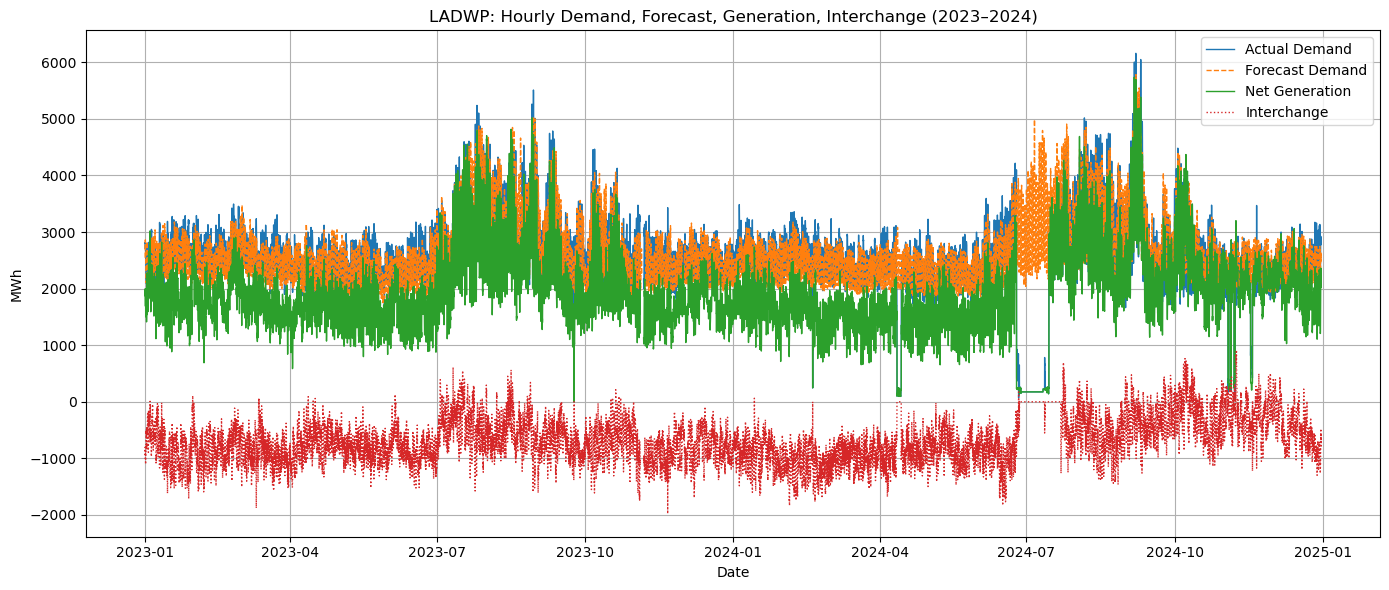


=== DONE! Fetched all 2023–2024 data in ascending order with pagination ===


In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

api_key = "RqRq7h51fUy2Pqsq8dO3R03hkm1JELAflsF8HvSq"


###############################################################################
# 1) DAILY FUEL-TYPE DATA (All Rows, Ascending)
###############################################################################
print("\n=== PART 1: DAILY FUEL-TYPE DATA (FULL) ===")

# We'll paginate so we get everything from 2023-01-01 to 2024-12-31
base_url_daily_fuel = "https://api.eia.gov/v2/electricity/rto/daily-fuel-type-data/data/"
params_daily_fuel = {
    "api_key": api_key,
    "frequency": "daily",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01",
    "end": "2024-12-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",  # get oldest data first
    "offset": 0,
    "length": 5000
}

all_daily_fuel_records = []
while True:
    response = requests.get(base_url_daily_fuel, params=params_daily_fuel)
    data_json = response.json()

    if "error" in data_json:
        print("API Error [Daily Fuel-Type]:", data_json["error"])
        break

    batch = data_json["response"]["data"]
    print(f"Fetched {len(batch)} rows (offset={params_daily_fuel['offset']})")

    if not batch:
        break

    all_daily_fuel_records.extend(batch)
    params_daily_fuel["offset"] += 5000

    time.sleep(0.2)  # polite pause

df_daily_fuel = pd.DataFrame(all_daily_fuel_records)

if not df_daily_fuel.empty:
    # Clean
    df_daily_fuel["period"] = pd.to_datetime(df_daily_fuel["period"])
    df_daily_fuel["value"] = df_daily_fuel["value"].astype(float)
    df_daily_fuel.rename(columns={"value": "MWh"}, inplace=True)

    # Quick summary by fuel type
    summary = df_daily_fuel.groupby("fueltype")["MWh"].sum().sort_values(ascending=False)
    print("\nTotal MWh by Fuel Type (Daily Fuel):")
    print(summary)

    # Pivot for plotting
    pivot_df_daily_fuel = df_daily_fuel.pivot_table(values="MWh", index="period", columns="fueltype", aggfunc="sum")
    pivot_df_daily_fuel.sort_index(inplace=True)

    # Plot
    pivot_df_daily_fuel.plot(figsize=(14, 6))
    plt.title("LADWP Daily Generation by Fuel Type (Full 2023–2024)")
    plt.xlabel("Date")
    plt.ylabel("MWh")
    plt.grid(True)
    plt.legend(title="Fuel Type")
    plt.tight_layout()
    plt.show()

    # Save CSV (optional)
    # df_daily_fuel.to_csv("ladwp_daily_fueltype_data_FULL.csv", index=False)
else:
    print("No data returned for daily fuel-type endpoint.")



###############################################################################
# 2) HOURLY FUEL-TYPE DATA (All Rows, Ascending)
###############################################################################
print("\n=== PART 2: HOURLY FUEL-TYPE DATA (FULL) ===")

base_url_hourly_fuel = "https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/"
params_hourly_fuel = {
    "api_key": api_key,
    "frequency": "hourly",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01T00",
    "end": "2024-12-31T00",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",  # oldest first
    "offset": 0,
    "length": 5000
}

all_hourly_fuel_records = []
while True:
    response = requests.get(base_url_hourly_fuel, params=params_hourly_fuel)
    data_json = response.json()

    if "error" in data_json:
        print("API Error [Hourly Fuel-Type]:", data_json["error"])
        break

    batch = data_json["response"]["data"]
    print(f"Fetched {len(batch)} rows with offset {params_hourly_fuel['offset']}")

    if not batch:
        break

    all_hourly_fuel_records.extend(batch)
    params_hourly_fuel["offset"] += 5000

    time.sleep(0.2)  # polite pause

df_hourly_fuel = pd.DataFrame(all_hourly_fuel_records)

if not df_hourly_fuel.empty:
    df_hourly_fuel["period"] = pd.to_datetime(df_hourly_fuel["period"])
    df_hourly_fuel["value"] = df_hourly_fuel["value"].astype(float)
    df_hourly_fuel.rename(columns={"value": "MWh"}, inplace=True)

    # Summary
    summary = df_hourly_fuel.groupby("fueltype")["MWh"].sum().sort_values(ascending=False)
    print("\n✅ Total MWh by Fuel Type (Full Hourly 2023–2024):")
    print(summary)

    # Pivot
    pivot_df_hourly_fuel = df_hourly_fuel.pivot_table(values="MWh", index="period", columns="fueltype", aggfunc="sum")
    pivot_df_hourly_fuel.sort_index(inplace=True)

    # Show time range
    print("\nDate range:", pivot_df_hourly_fuel.index.min(), "to", pivot_df_hourly_fuel.index.max())

    # Plot one sample window
    subset = pivot_df_hourly_fuel.loc["2023-07-01":"2023-07-08"]

    fig, ax = plt.subplots(figsize=(14, 6))
    subset.plot(ax=ax)
    ax.set_title("LADWP Hourly Generation by Fuel Type (Jul 1–8, 2023)")
    ax.set_xlabel("Month")
    ax.set_ylabel("MWh")
    ax.legend(title="Fuel Type", bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Save full CSV (optional)
    # df_hourly_fuel.to_csv("ladwp_all_hourly_fueltype_data_FULL.csv", index=False)
else:
    print("No data returned for hourly fuel-type endpoint.")



###############################################################################
# 3) DAILY REGION DATA (All Rows, Ascending)
###############################################################################
print("\n=== PART 3: DAILY REGION DATA (FULL) ===")

base_url_daily_region = "https://api.eia.gov/v2/electricity/rto/daily-region-data/data/"
params_daily_region = {
    "api_key": api_key,
    "frequency": "daily",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01",
    "end": "2024-12-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000
}

all_daily_region_records = []
while True:
    response = requests.get(base_url_daily_region, params=params_daily_region)
    data_json = response.json()

    if "error" in data_json:
        print("API Error [Daily Region]:", data_json["error"])
        break

    batch = data_json["response"]["data"]
    print(f"Fetched {len(batch)} rows (offset={params_daily_region['offset']})")

    if not batch:
        break

    all_daily_region_records.extend(batch)
    params_daily_region["offset"] += 5000

    time.sleep(0.2)

df_daily_region = pd.DataFrame(all_daily_region_records)

if not df_daily_region.empty:
    df_daily_region["period"] = pd.to_datetime(df_daily_region["period"])
    df_daily_region["value"] = df_daily_region["value"].astype(float)

    # Pivot for (D, DF, NG, TI)
    df_pivot_daily_region = df_daily_region.pivot_table(values="value", index="period", columns="type", aggfunc="first")
    df_pivot_daily_region.sort_index(inplace=True)

    print("\nAvailable metrics (Daily Region):", df_pivot_daily_region.columns.tolist())
    print("Date range:", df_pivot_daily_region.index.min(), "to", df_pivot_daily_region.index.max())

    # Plot actual demand, forecast, generation, and interchange
    plt.figure(figsize=(14, 6))

    if "D" in df_pivot_daily_region.columns:
        plt.plot(df_pivot_daily_region.index, df_pivot_daily_region["D"], label="Actual Demand", linewidth=2)

    if "DF" in df_pivot_daily_region.columns:
        plt.plot(df_pivot_daily_region.index, df_pivot_daily_region["DF"], label="Forecast Demand", linestyle='--', linewidth=2)

    if "NG" in df_pivot_daily_region.columns:
        plt.plot(df_pivot_daily_region.index, df_pivot_daily_region["NG"], label="Net Generation", linewidth=2)

    if "TI" in df_pivot_daily_region.columns:
        plt.plot(df_pivot_daily_region.index, df_pivot_daily_region["TI"], label="Interchange (Net Imports)", linestyle=':', linewidth=2)

    plt.title("LADWP: Daily Demand, Forecast, Generation, Interchange (2023–2024)")
    plt.xlabel("Date")
    plt.ylabel("MWh")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Save CSV
    # df_pivot_daily_region.to_csv("ladwp_daily_region_data_FULL.csv")
else:
    print("No data returned for daily region endpoint.")



###############################################################################
# 4) HOURLY REGION DATA (All Rows, Ascending)
###############################################################################
print("\n=== PART 4: HOURLY REGION DATA (FULL) ===")

base_url_hourly_region = "https://api.eia.gov/v2/electricity/rto/region-data/data/"
params_hourly_region = {
    "api_key": api_key,
    "frequency": "hourly",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01T00",
    "end": "2024-12-31T00",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000
}

all_hourly_region_records = []
while True:
    response = requests.get(base_url_hourly_region, params=params_hourly_region)
    data_json = response.json()

    if "error" in data_json:
        print("API Error [Hourly Region]:", data_json["error"])
        break

    batch = data_json["response"]["data"]
    print(f"Fetched {len(batch)} rows (offset={params_hourly_region['offset']})")

    if not batch:
        break

    all_hourly_region_records.extend(batch)
    params_hourly_region["offset"] += 5000

    time.sleep(0.2)

df_hourly_region = pd.DataFrame(all_hourly_region_records)

if not df_hourly_region.empty:
    df_hourly_region["period"] = pd.to_datetime(df_hourly_region["period"])
    df_hourly_region["value"] = df_hourly_region["value"].astype(float)

    df_pivot_hourly_region = df_hourly_region.pivot_table(values="value", index="period", columns="type", aggfunc="first")
    df_pivot_hourly_region.sort_index(inplace=True)

    print("\nAvailable metrics (Hourly Region):", df_pivot_hourly_region.columns.tolist())
    print("Date range:", df_pivot_hourly_region.index.min(), "to", df_pivot_hourly_region.index.max())

    # Plot sample
    fig, ax = plt.subplots(figsize=(14, 6))
    # Plot D, DF, NG, TI if they exist
    if "D" in df_pivot_hourly_region.columns:
        ax.plot(df_pivot_hourly_region.index, df_pivot_hourly_region["D"], label="Actual Demand", linewidth=1)
    if "DF" in df_pivot_hourly_region.columns:
        ax.plot(df_pivot_hourly_region.index, df_pivot_hourly_region["DF"], label="Forecast Demand", linestyle='--', linewidth=1)
    if "NG" in df_pivot_hourly_region.columns:
        ax.plot(df_pivot_hourly_region.index, df_pivot_hourly_region["NG"], label="Net Generation", linewidth=1)
    if "TI" in df_pivot_hourly_region.columns:
        ax.plot(df_pivot_hourly_region.index, df_pivot_hourly_region["TI"], label="Interchange", linestyle=':', linewidth=1)

    ax.set_title("LADWP: Hourly Demand, Forecast, Generation, Interchange (2023–2024)")
    ax.set_xlabel("Date")
    ax.set_ylabel("MWh")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # Save CSV
    # df_pivot_hourly_region.to_csv("ladwp_hourly_region_data_FULL.csv")
else:
    print("No data returned for hourly region endpoint.")


print("\n=== DONE! Fetched all 2023–2024 data in ascending order with pagination ===")


# Save as CSV

In [7]:
import requests
import pandas as pd
import time



###############################################################################
# Helper Function for Pagination
###############################################################################
def fetch_all_data(base_url, params):
    """
    Fetches all rows from the EIA API, given a base_url and initial params.
    Increments params['offset'] by 5000 each loop until no more data is returned.
    Returns a list of all records.
    """
    all_records = []
    while True:
        response = requests.get(base_url, params=params)
        data_json = response.json()

        if "error" in data_json:
            print("API Error:", data_json["error"])
            break

        batch = data_json["response"]["data"]
        print(f"Fetched {len(batch)} rows (offset={params['offset']})")

        if not batch:
            # no more data returned
            break

        all_records.extend(batch)
        params["offset"] += 5000

        # Polite pause
        time.sleep(0.2)

    return all_records


###############################################################################
# 1) DAILY GENERATION BY FUEL TYPE (Full Data)
###############################################################################
print("\n=== 1) DAILY FUEL-TYPE DATA (Full) ===")

# Base URL
base_url_daily_fuel = "https://api.eia.gov/v2/electricity/rto/daily-fuel-type-data/data/"

# Query Params
params_daily_fuel = {
    "api_key": api_key,
    "frequency": "daily",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01",
    "end": "2024-12-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",  # ascending so we get earliest -> latest
    "offset": 0,
    "length": 5000
}

daily_fuel_records = fetch_all_data(base_url_daily_fuel, params_daily_fuel)
df_daily_fuel = pd.DataFrame(daily_fuel_records)

if not df_daily_fuel.empty:
    # Clean
    df_daily_fuel["period"] = pd.to_datetime(df_daily_fuel["period"])
    df_daily_fuel["value"] = df_daily_fuel["value"].astype(float)

    # Pivot for wide format
    pivot_daily_fuel = df_daily_fuel.pivot_table(
        values="value",
        index="period",
        columns="fueltype",
        aggfunc="sum"
    )
    pivot_daily_fuel.sort_index(inplace=True)

    # Reset index and rename for a clean CSV
    pivot_daily_fuel_reset = pivot_daily_fuel.reset_index().rename(columns={"period": "Date"})
    pivot_daily_fuel_reset.to_csv("ladwp_daily_fueltype_data_FULL.csv", index=False)
    print("Saved 'ladwp_daily_fueltype_data_FULL.csv' with all daily fuel-type data.")
    print("Daily Fuel Type Date Range:", pivot_daily_fuel.index.min(), "to", pivot_daily_fuel.index.max())
else:
    print("No data returned for daily fuel-type endpoint.")


###############################################################################
# 2) DAILY REGION DATA (Full)
###############################################################################
print("\n=== 2) DAILY REGION DATA (Full) ===")

base_url_daily_region = "https://api.eia.gov/v2/electricity/rto/daily-region-data/data/"

params_daily_region = {
    "api_key": api_key,
    "frequency": "daily",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01",
    "end": "2024-12-31",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000
}

daily_region_records = fetch_all_data(base_url_daily_region, params_daily_region)
df_daily_region = pd.DataFrame(daily_region_records)

if not df_daily_region.empty:
    # Clean
    df_daily_region["period"] = pd.to_datetime(df_daily_region["period"])
    df_daily_region["value"] = df_daily_region["value"].astype(float)

    # Pivot for wide format (D, DF, NG, TI)
    pivot_daily_region = df_daily_region.pivot_table(
        values="value",
        index="period",
        columns="type",
        aggfunc="first"
    )
    pivot_daily_region.sort_index(inplace=True)

    # Reset index and rename
    pivot_daily_region_reset = pivot_daily_region.reset_index().rename(columns={"period": "Date"})
    pivot_daily_region_reset.to_csv("ladwp_daily_region_data_FULL.csv", index=False)
    print("Saved 'ladwp_daily_region_data_FULL.csv' with all daily region data.")
    print("Daily Region Date Range:", pivot_daily_region.index.min(), "to", pivot_daily_region.index.max())
else:
    print("No data returned for daily region endpoint.")


###############################################################################
# 3) HOURLY GENERATION BY FUEL TYPE (Full)
###############################################################################
print("\n=== 3) HOURLY FUEL-TYPE DATA (Full) ===")

base_url_hourly_fuel = "https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/"

params_hourly_fuel = {
    "api_key": api_key,
    "frequency": "hourly",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01T00",
    "end": "2024-12-31T00",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000
}

hourly_fuel_records = fetch_all_data(base_url_hourly_fuel, params_hourly_fuel)
df_hourly_fuel = pd.DataFrame(hourly_fuel_records)

if not df_hourly_fuel.empty:
    # Clean
    df_hourly_fuel["period"] = pd.to_datetime(df_hourly_fuel["period"])
    df_hourly_fuel["value"] = df_hourly_fuel["value"].astype(float)

    # Pivot
    pivot_hourly_fuel = df_hourly_fuel.pivot_table(
        values="value",
        index="period",
        columns="fueltype",
        aggfunc="sum"
    )
    pivot_hourly_fuel.sort_index(inplace=True)

    pivot_hourly_fuel_reset = pivot_hourly_fuel.reset_index().rename(columns={"period": "Date"})
    pivot_hourly_fuel_reset.to_csv("ladwp_hourly_fueltype_data_FULL.csv", index=False)
    print("Saved 'ladwp_hourly_fueltype_data_FULL.csv' with all hourly fuel-type data.")
    print("Hourly Fuel Type Date Range:", pivot_hourly_fuel.index.min(), "to", pivot_hourly_fuel.index.max())
else:
    print("No data returned for hourly fuel-type endpoint.")


###############################################################################
# 4) HOURLY REGION DATA (Full)
###############################################################################
print("\n=== 4) HOURLY REGION DATA (Full) ===")

base_url_hourly_region = "https://api.eia.gov/v2/electricity/rto/region-data/data/"

params_hourly_region = {
    "api_key": api_key,
    "frequency": "hourly",
    "data[0]": "value",
    "facets[respondent][]": "LDWP",
    "start": "2023-01-01T00",
    "end": "2024-12-31T00",
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    "offset": 0,
    "length": 5000
}

hourly_region_records = fetch_all_data(base_url_hourly_region, params_hourly_region)
df_hourly_region = pd.DataFrame(hourly_region_records)

if not df_hourly_region.empty:
    df_hourly_region["period"] = pd.to_datetime(df_hourly_region["period"])
    df_hourly_region["value"] = df_hourly_region["value"].astype(float)

    # Pivot (D, DF, NG, TI)
    pivot_hourly_region = df_hourly_region.pivot_table(
        values="value",
        index="period",
        columns="type",
        aggfunc="first"
    )
    pivot_hourly_region.sort_index(inplace=True)

    pivot_hourly_region_reset = pivot_hourly_region.reset_index().rename(columns={"period": "Date"})
    pivot_hourly_region_reset.to_csv("ladwp_hourly_region_data_FULL.csv", index=False)
    print("Saved 'ladwp_hourly_region_data_FULL.csv' (Hourly Region Data).")
    print("Hourly Region Date Range:", pivot_hourly_region.index.min(), "to", pivot_hourly_region.index.max())
else:
    print("No data returned for hourly region endpoint.")


print("\n=== DONE! 4 CSV files created with full date ranges in ascending order. ===")



=== 1) DAILY FUEL-TYPE DATA (Full) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 5000 rows (offset=10000)
Fetched 5000 rows (offset=15000)
Fetched 1368 rows (offset=20000)
Fetched 0 rows (offset=25000)
Saved 'ladwp_daily_fueltype_data_FULL.csv' with all daily fuel-type data.
Daily Fuel Type Date Range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

=== 2) DAILY REGION DATA (Full) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 4549 rows (offset=10000)
Fetched 0 rows (offset=15000)
Saved 'ladwp_daily_region_data_FULL.csv' with all daily region data.
Daily Region Date Range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

=== 3) HOURLY FUEL-TYPE DATA (Full) ===
Fetched 5000 rows (offset=0)
Fetched 5000 rows (offset=5000)
Fetched 5000 rows (offset=10000)
Fetched 5000 rows (offset=15000)
Fetched 5000 rows (offset=20000)
Fetched 5000 rows (offset=25000)
Fetched 5000 rows (offset=30000)
Fetched 5000 rows (offset=35000)
Fetched 5000 rows (offset=4